## Clusterizaciòn de codificaciones

## Importación de librerias necesarias

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
from pyspark.sql import functions as F, types as T, DataFrame, Window

In [4]:
from src.utils.spark import SparkUtils
spark_utils = SparkUtils('clusterize_encodings')
spark = spark_utils.spark

2025-09-29 16:19:20.689983: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
25/09/29 16:20:25 WARN Utils: Your hostname, edgar-MS-7C96 resolves to a loopback address: 127.0.1.1; using 192.168.1.33 instead (on interface enp34s0)
25/09/29 16:20:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-conda-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b7e3b65b-093e-4778-b96b-1aea28c4cbbe;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 182ms :: artifacts dl 5ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [ ]:
REGENERATE_INTERMEDIATE_TABLES = False

## Cargar informaciòn de codificaciones

In [ ]:
avg_encoded_split_with_embeddings = spark.read.format('delta').load(spark_utils.path(
    'avg_encoded_split_with_embeddings', catalog = 'silver.models'
))

In [6]:
avg_encoded_split_with_embeddings.show(3)

+-----------+--------------------+
|parent_asin|       avg_embedding|
+-----------+--------------------+
| 1573340626|[-0.026071703, -0...|
| 6875467534|[-0.036832564, 0....|
| B000000O2M|[-0.06753392, 0.0...|
+-----------+--------------------+
only showing top 3 rows



In [8]:
if REGENERATE_INTERMEDIATE_TABLES:
    import cudf
    import cupy as cp
    from cuml.cluster import KMeans
    from pyspark.sql import SparkSession
    import pandas as pd
    import numpy as np


    pdf = avg_encoded_split_with_embeddings.select("parent_asin", "avg_embedding").toPandas()

    embeddings = np.vstack(pdf["avg_embedding"].values)

    gdf = cudf.DataFrame(embeddings)

    gpu_count = cp.cuda.runtime.getDeviceCount()
    print("CUDA GPU count:", gpu_count)

    kmeans = KMeans(n_clusters=200, max_iter=300)
    kmeans.fit(gdf)

    gdf["cluster"] = kmeans.labels_

    result_pdf = pdf.copy()
    result_pdf["cluster"] = gdf["cluster"].to_pandas()

    result_spark_df = spark.createDataFrame(result_pdf)

    (
        result_spark_df.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('avg_encoded_split_with_embeddings_clustered', catalog = 'silver.models'))
    )
    

CUDA GPU count: 1


In [ ]:
avg_encoded_split_with_embeddings = spark.read.format('delta').load(spark_utils.path(
    'avg_encoded_split_with_embeddings_clustered', catalog = 'silver.models'
))
avg_encoded_split_with_embeddings.show(3)

+-----------+--------------------+-------+
|parent_asin|       avg_embedding|cluster|
+-----------+--------------------+-------+
| 9981724580|[-0.0162825062870...|    114|
| B00000JD77|[-0.0070069334469...|     78|
| B00000SG9M|[-0.0326500013470...|    121|
+-----------+--------------------+-------+
only showing top 3 rows



In [7]:
avg_encoded_split_with_embeddings.sample(0.02).toPandas()

,parent_asin,avg_embedding,cluster
0,B00006D2LG,"[0.027723437175154686, 0.0004088511341251433, ...",115
1,B0002J2TLC,"[0.017071517184376717, 0.011969010345637798, 0...",70
2,B000IZBJ5C,"[-0.010344704613089561, 0.04532015696167946, 0...",158
3,B000SEH9SY,"[-0.045088913291692734, 0.01952982507646084, 0...",99
4,B0013F6NBG,"[-0.000428025727160275, -0.03396397456526756, ...",116
...,...,...,...
842,B0032FOJPM,"[-0.02526005730032921, 0.017898570746183395, -...",164
843,B0002A9TJQ,"[-0.02506759762763977, -0.0143791688606143, 0....",62
844,B0002K6F66,"[-0.02149936929345131, 0.0073419068939983845, ...",103
845,B002A96WMY,"[-0.016825785860419273, -0.021911894902586937,...",95


## Visualizar distribuciòn de codificaciones

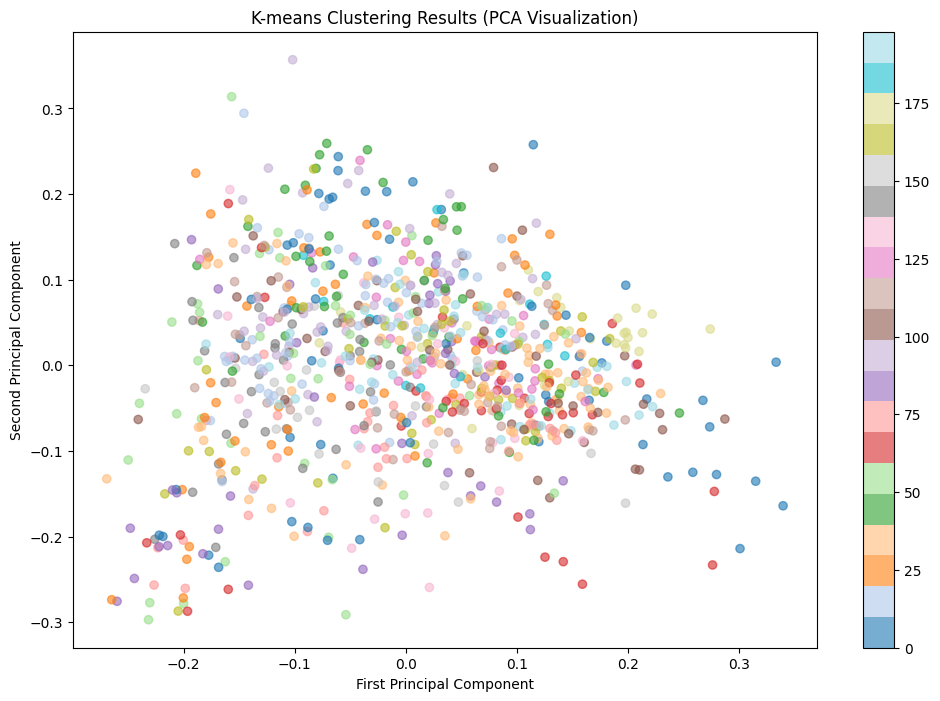

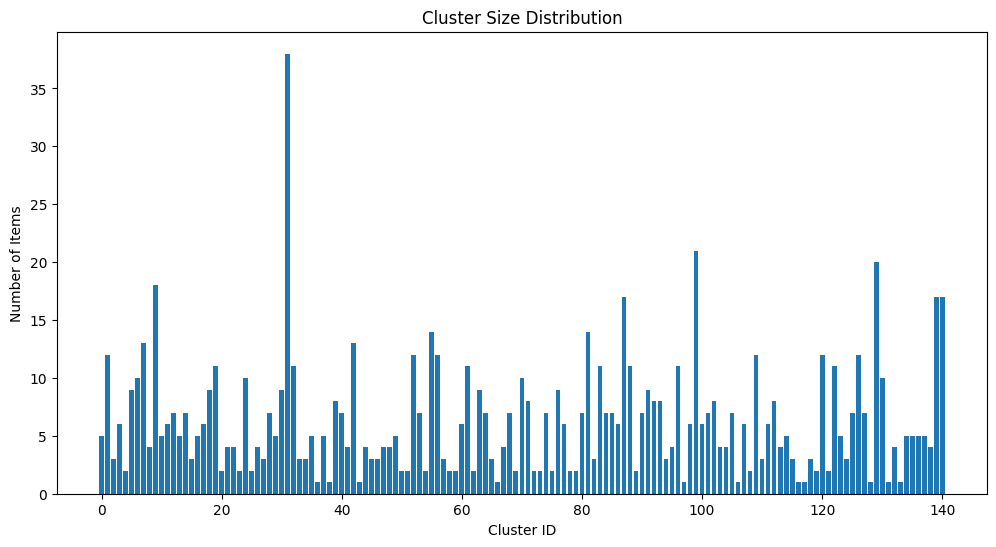

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

df_pandas = avg_encoded_split_with_embeddings.sample(0.02).toPandas()
embeddings = np.array(df_pandas['avg_embedding'].tolist())

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     c=df_pandas['cluster'], cmap='tab20', alpha=0.6)
plt.colorbar(scatter)
plt.title('K-means Clustering Results (PCA Visualization)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

cluster_counts = df_pandas['cluster'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(range(len(cluster_counts)), cluster_counts.values)
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()


In [ ]:
avg_encoded_split_with_embeddings_counts = (
    avg_encoded_split_with_embeddings
        .groupBy('cluster')
        .count()
        .orderBy('cluster')
).toPandas()

,cluster,count
0,0,319
1,1,887
2,2,357
3,3,385
4,4,121


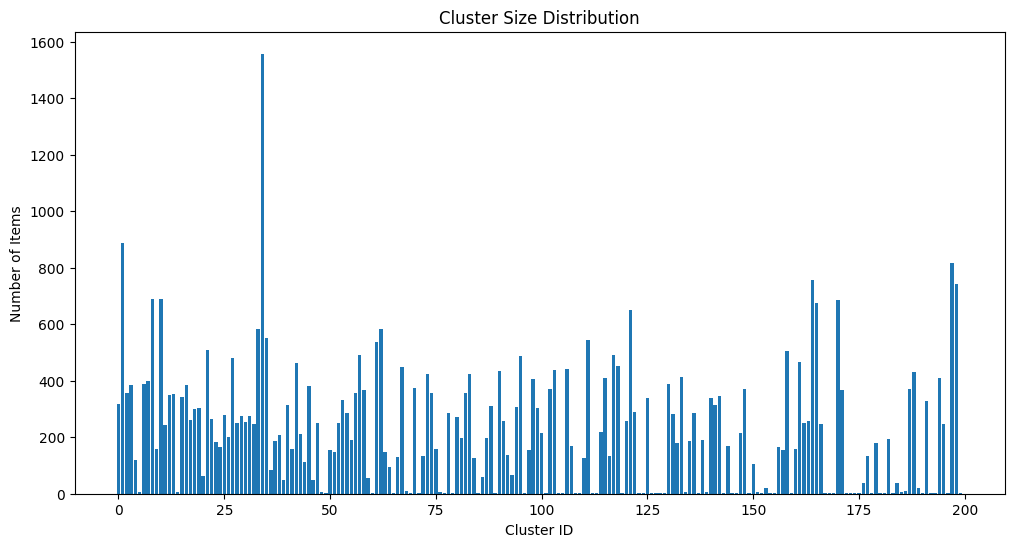

In [14]:
plt.figure(figsize=(12, 6))
plt.bar(
    avg_encoded_split_with_embeddings_counts['cluster'],
    avg_encoded_split_with_embeddings_counts['count']
)
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()

In [9]:
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.cluster import KMeans

X = embeddings_2d
labels = df_pandas["cluster"].values

print("Silhouette Score:", silhouette_score(X, labels))
print("Calinski–Harabasz Index:", calinski_harabasz_score(X, labels))
print("Davies–Bouldin Index:", davies_bouldin_score(X, labels))
print("Inertia (WCSS):", KMeans(n_clusters=len(set(labels)), random_state=42).fit(X).inertia_)


Silhouette Score: -0.43877502924948136
Calinski–Harabasz Index: 21.173715380587918
Davies–Bouldin Index: 13.107722005951128
Inertia (WCSS): 0.12983704566673454


In [10]:
meta_items = spark.read.format('delta').load(spark_utils.path('meta_items', 'bronze'))

In [18]:
meta_items.filter(F.col('parent_asin') == 'B00000SG9M').show(1)

+--------------------+--------------------+--------------------+--------------------+--------------+-------------+-----+---------------+-----------+--------------------+--------------------+--------------------+
|               title|       main_category|            features|         description|average_rating|rating_number|price|          store|parent_asin|          categories|             details|              images|
+--------------------+--------------------+--------------------+--------------------+--------------+-------------+-----+---------------+-----------+--------------------+--------------------+--------------------+
|Sensory Science R...|Home Audio & Theater|[64 MB built-in m...|[MP3newswire.net,...|           3.0|           53| NULL|Sensory Science| B00000SG9M|[Electronics, Por...|{"Product Dimensi...|[{"thumb":"https:...|
+--------------------+--------------------+--------------------+--------------------+--------------+-------------+-----+---------------+-----------+----

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
import tensorflow_hub as hub
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from src.utils import SparkUtils

In [7]:
from src.utils.spark import SparkUtils

In [8]:
!nvidia-smi

Sun Sep 28 14:56:21 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.247.01             Driver Version: 535.247.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3050        Off | 00000000:10:00.0  On |                  N/A |
|  0%   51C    P2              21W /  70W |    820MiB /  6144MiB |     14%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [9]:
spark_utils = SparkUtils('encoding')
spark = spark_utils.spark

2025-09-28 14:56:22,114 - SparkCreator - INFO - Starts creating environment


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ad286959-64ed-48fb-96eb-8399d8031477;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 110ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [10]:
REGENERATE_INTERMEDIATE_TABLES = False

In [11]:
from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window

## Importar información transformada

In [12]:
items_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = 'silver.preprocess'
))

In [13]:
if REGENERATE_INTERMEDIATE_TABLES:
    main_category_encoded_split = (
        items_category_encoded
            .select(
                F.col('parent_asin'),
                F.explode(F.split(
                    'colapsed_text',
                    '\\.'
                )).alias('colapsed_text_split')
            )
            .withColumn(
                'colapsed_text_split',
                F.trim(F.col('colapsed_text_split'))
            )
            .withColumn(
                'record_id', F.row_number().over(
                    Window.orderBy(
                        F.col('parent_asin').asc(),
                        F.col('colapsed_text_split').asc()
                    )
                )
            )
    )

    (
        main_category_encoded_split.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('main_category_encoded_split', catalog = 'silver.models'))
    )
    
main_category_encoded_split = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded_split', catalog = 'silver.models'
))

In [14]:
main_category_encoded_split.filter(F.col('parent_asin') == '0594514843').show(1)

+-----------+--------------------+---------+
|parent_asin| colapsed_text_split|record_id|
+-----------+--------------------+---------+
| 0594514843|Custom clip mecha...|      201|
+-----------+--------------------+---------+
only showing top 1 row



## Codificar textos generados en proceso de limpieza de datos

In [15]:
MODULE_URL = "https://tfhub.dev/google/universal-sentence-encoder-large/5"
model = hub.load( MODULE_URL )

2025-09-28 10:22:22,797 - absl - INFO - Using /mnt/d/Maestría/Amazon Reviews Code/tf_cache to cache modules.
I0000 00:00:1759072943.629932  361837 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3641 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:10:00.0, compute capability: 8.6
2025-09-28 10:22:30,655 - absl - INFO - Fingerprint not found. Saved model loading will continue.
2025-09-28 10:22:30,655 - absl - INFO - path_and_singleprint metric could not be logged. Saved model loading will continue.


In [ ]:
@F.pandas_udf(returnType=T.ArrayType(T.FloatType()))
def encode_texts_split(texts: pd.Series) -> pd.Series:
    model = hub.load(MODULE_URL)
    text_list = [str(text) if pd.notna(text) and text != "" else "" for text in texts]
    embeddings = model(text_list).numpy()
    return pd.Series([embedding.tolist() for embedding in embeddings])

main_category_encoded_split_with_embeddings = main_category_encoded_split.withColumn(
    "text_embeddings", 
    encode_texts_split(F.col("colapsed_text_split"))
)


In [ ]:
main_category_encoded_split.select('parent_asin').distinct().count()

694836

In [16]:
main_category_encoded_split_sample = (
    main_category_encoded_split
        .withColumn('id2', F.dense_rank().over(
            Window.orderBy('parent_asin')
        ))
        .filter(F.col('id2') <= 100_000)
        .drop('id2')
)

In [17]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        main_category_encoded_split_sample.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('main_category_encoded_split_sample', catalog='silver.models'))
    )

main_category_encoded_split_sample = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded_split_sample', catalog = 'silver.models'
))
main_category_encoded_split_sample.count()

2643697

In [28]:
main_category_encoded_split_with_embeddings_sample_3 = spark.read.format('parquet').load(spark_utils.path(
    'main_category_encoded_split_with_embeddings_sample_3', catalog = 'silver.models'
))

In [29]:
main_category_encoded_split_with_embeddings_sample_3.count()

1315000

In [30]:
main_category_encoded_split_with_embeddings_sample_2 = spark.read.format('parquet').load(spark_utils.path(
    'main_category_encoded_split_with_embeddings_sample_2', catalog = 'silver.models'
))

In [32]:
main_category_encoded_split_with_embeddings_sample_3.count()

1315000

In [31]:
main_category_encoded_split_with_embeddings_sample_2.count()

1315000

In [26]:
(
    main_category_encoded_split_with_embeddings_sample_2.alias('A')
        .join(
            main_category_encoded_split_sample.alias('B'),
            on = 'record_id',
            how = 'left'
        )
        .select('B.parent_asin')
        .distinct()
).count()

44458

In [27]:
import tensorflow_hub as hub
import numpy as np
from pyspark.sql import Window, functions as F

model = hub.load(MODULE_URL)

def embed_batch(texts, batch_size=1024):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        emb = model(batch).numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

def process_to_parquet(df, col: str, id_col: str, batch_size: int, tf_batch: int, parquet_path: str):
    w = Window.orderBy(id_col)
    df_idx = df.withColumn("rn", F.row_number().over(w))
    count = df.count()
    print("====Parquets to process=====", count)
    offset = 0
    batch_idx = 0
    while offset < count:
        print("Offset: ",offset, end="\t")
        batch_df = (
            df_idx
            .filter((F.col("rn") > offset) & (F.col("rn") <= offset + batch_size))
            .select(id_col, col)
        )
        pdf = batch_df.toPandas()
        texts = pdf[col].fillna("").astype(str).tolist()
        embs = embed_batch(texts, batch_size=tf_batch)
        emb_df = spark.createDataFrame(
            list(zip(pdf[id_col].tolist(), embs.tolist())),
            schema=[id_col, "text_embeddings"]
        )
        mode = "overwrite" if batch_idx == 0 else "append"
        emb_df.write.mode(mode).parquet(parquet_path)
        offset += batch_size
        batch_idx += 1

process_to_parquet(
    main_category_encoded_split_sample,
    col="colapsed_text_split",
    id_col="record_id",
    batch_size=5000,
    tf_batch=256,
    parquet_path=spark_utils.path('main_category_encoded_split_with_embeddings_sample_3', catalog='silver.models')
)

2025-09-28 11:38:31,228 - absl - INFO - Fingerprint not found. Saved model loading will continue.
2025-09-28 11:38:31,228 - absl - INFO - path_and_singleprint metric could not be logged. Saved model loading will continue.


====Parquets to process===== 2643697
====Processing batch===== 0 offset 0


====Processing batch===== 1 offset 5000


====Processing batch===== 2 offset 10000


====Processing batch===== 3 offset 15000


...

====Processing batch===== 261 offset 1305000


====Processing batch===== 262 offset 1310000


====Processing batch===== 263 offset 1315000


2025-09-28 12:21:01.541161: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.82GiB (rounded to 1950875648)requested by op StatefulPartitionedCall/StatefulPartitionedCall/EncoderTransformer/Transformer/SparseTransformerEncode/Layer_0/SelfAttention/SparseMultiheadAttention/DotProductAttention/MatMul
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-09-28 12:21:01.541268: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
2025-09-28 12:21:01.541278: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 1631, Chunks in use: 1630. 407.8KiB allocated for chunks. 407.5KiB in use in bin. 108.1KiB client-requested in use in bin.
2025-09-28 12:21:01.541284: I external/local_xla/xla/tsl/fram

ResourceExhaustedError: Graph execution error:

Detected at node EncoderTransformer/Transformer/SparseTransformerEncode/Layer_0/SelfAttention/SparseMultiheadAttention/DotProductAttention/MatMul defined at (most recent call last):
<stack traces unavailable>
OOM when allocating tensor with shape[256,8,488,488] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc
	 [[{{node EncoderTransformer/Transformer/SparseTransformerEncode/Layer_0/SelfAttention/SparseMultiheadAttention/DotProductAttention/MatMul}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.
 [Op:__inference_restored_function_body_215439]

In [ ]:
main_category_encoded_split_with_embeddings_sample = spark.read.format('parquet').load(spark_utils.path(
    'main_category_encoded_split_with_embeddings_sample', catalog = 'silver.models'
))

In [22]:
main_category_encoded_split_with_embeddings_sample.select(F.col('parent_asin')).distinct().count()

NameError: name 'main_category_encoded_split_with_embeddings_sample' is not defined

In [ ]:
if True:

    (
        main_category_encoded_split_with_embeddings_sample.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('main_category_encoded_split_with_embeddings_sample', catalog = 'silver.models'))
    )
    
main_category_encoded_split_with_embeddings_sample = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded_split_with_embeddings_sample', catalog = 'silver.models'
))

2025-09-28 08:12:01.367601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-28 08:12:01.367600: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1759065127.902618  155529 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1254 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1759065127.905117  155531 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1254 MB memory:  -

08:12:22.821 [Executor task launch worker for task 0.0 in stage 10.0 (TID 107)] ERROR org.apache.spark.executor.Executor - Exception in task 0.0 in stage 10.0 (TID 107)
org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/tmp/ipykernel_153519/820964880.py", line 3, in encode_texts_split
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow_hub/module_v2.py", line 126, in load
    obj = tf.compat.v1.saved_model.load_v2(module_path, tags=tags)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow/python/saved_model/load.py", line 912, in load
    result = load_partial(export_dir, None, tags, options)["root"]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow

2025-09-28 08:12:23.546943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PythonException: 
  An exception was thrown from the Python worker. Please see the stack trace below.
Traceback (most recent call last):
  File "/tmp/ipykernel_153519/820964880.py", line 3, in encode_texts_split
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow_hub/module_v2.py", line 126, in load
    obj = tf.compat.v1.saved_model.load_v2(module_path, tags=tags)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow/python/saved_model/load.py", line 912, in load
    result = load_partial(export_dir, None, tags, options)["root"]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/edgar/Desktop/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/tensorflow/python/saved_model/load.py", line 1044, in load_partial
    except errors.NotFoundError as err:
  File "/home/e

Traceback (most recent call last):
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 74, in worker
    worker_main(infile, outfile)
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/worker.py", line 1291, in main
    if read_int(infile) == SpecialLengths.END_OF_STREAM:
       ^^^^^^^^^^^^^^^^
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/pyspark/python/lib/pyspark.zip/pyspark/serializers.py", line 596, in read_int
    raise EOFError
EOFError


In [ ]:
main_category_encoded_split_with_embeddings.show(3)

2025-09-28 07:51:02.538937: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1759063869.068996  121346 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:10:00.0, compute capability: 8.6


+-----------+--------------------+---------+--------------------+
|parent_asin| colapsed_text_split|record_id|     text_embeddings|
+-----------+--------------------+---------+--------------------+
| 0110400550| 100% Brand New, ...|        1|[-0.04516362, 0.0...|
| 0110400550| Color: Pink and ...|        2|[-0.012929839, -0...|
| 0110400550| Precise openings...|        3|[-0.021753829, 0....|
+-----------+--------------------+---------+--------------------+
only showing top 3 rows



In [ ]:
items_category_encoded.count()

694836

In [ ]:
items_category_encoded.head(1)

[Row(title='Barnes & Noble FITS 6" TABLET / E-READER NOOK Simple Touch Oliver Cover RED', main_category='home_audio_theater', features=None, description=None, average_rating=None, rating_number=9, price=None, store=None, parent_asin='0594514843', categories=['Electronics', 'eBook Readers & Accessories'], details='{"Product Dimensions":"5.51 x 7.01 x 1 inches","Item Weight":"7.8 ounces","Manufacturer":"Barnes and Noble","Item model number":"9780594514848","Is Discontinued By Manufacturer":"No","Date First Available":"July 15, 2015","Brand":"Barnes & Noble","Color":"Red","Compatible Devices":"E-Readers","Form Factor":"Case","Material":"Faux Leather"}', images=None, description_colapsed='The Oliver Cover in Red for NOOK Simple Touch is designed to protect and safeguard your eBook reader. The Nook simple touch case has a smooth, comfortable synthetic leather exterior. Your Nook is held in place with a simple bar-clip, eliminating the need for straps. This Nook case provides easy access to 

In [ ]:
from pyspark.sql.functions import pandas_udf
import pyspark.sql.functions as F

In [ ]:
os.environ["TFHUB_CACHE_DIR"] = "/tmp/tfhub"

In [ ]:
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import UniversalSentenceEncoder
from pyspark.ml import Pipeline
import sparknlp

spark = sparknlp.start(gpu = True)

:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp-gpu_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-1778281b-113b-4459-9678-261e38e70eb0;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp-gpu_2.12;5.1.4 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-bundle;1.11.828 in central
	found com.github.universal-automata#liblevenshtein;3.0.0 in central
	found com.google.protobuf#protobuf-java-util;3.0.0-beta-3 in central
	found com.google.protobuf#protobuf-java;3.0.0-beta-3 in central
	found com.google.code.gson#gson;2.3 in central
	found it.unimi.dsi#fastutil;7.0.12 in central
	found org.projectlombok#lombok;1.16.8 in central
	found com.google.cloud#google-cloud-storage;2.20.1 in central
	found com.google.guava#guava;31.1-jre in central
	found com.google.guava#

In [ ]:


df = spark.createDataFrame([("This is a test",), ("Spark NLP works with USE",)], ["text"])

doc = DocumentAssembler().setInputCol("text").setOutputCol("document")
use = UniversalSentenceEncoder.pretrained("tfhub_use", "en") \
    .setInputCols(["document"]).setOutputCol("sentence_embeddings")

pipeline = Pipeline(stages=[doc, use])
model = pipeline.fit(df)
result = model.transform(df)

result.select("sentence_embeddings.embeddings").show(truncate=False)


tfhub_use download started this may take some time.
Approximate size to download 923.7 MB
[ / ]tfhub_use download started this may take some time.
Approximate size to download 923.7 MB
[ \ ]Download done! Loading the resource.
[ — ]
An error occurred while calling z:com.johnsnowlabs.nlp.pretrained.PythonResourceDownloader.downloadModel.
: java.lang.UnsatisfiedLinkError: no jnitensorflow in java.library.path: [/usr/lib/x86_64-linux-gnu, /usr/java/packages/lib, /usr/lib/x86_64-linux-gnu/jni, /lib/x86_64-linux-gnu, /usr/lib/x86_64-linux-gnu, /usr/lib/jni, /lib, /usr/lib]
	at java.base/java.lang.ClassLoader.loadLibrary(ClassLoader.java:2678)
	at java.base/java.lang.Runtime.loadLibrary0(Runtime.java:830)
	at java.base/java.lang.System.loadLibrary(System.java:1890)
	at org.bytedeco.javacpp.Loader.loadLibrary(Loader.java:1832)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1423)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1234)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1210)
	at

Py4JJavaError: An error occurred while calling z:com.johnsnowlabs.nlp.pretrained.PythonResourceDownloader.downloadModel.
: java.lang.UnsatisfiedLinkError: no jnitensorflow in java.library.path: [/usr/lib/x86_64-linux-gnu, /usr/java/packages/lib, /usr/lib/x86_64-linux-gnu/jni, /lib/x86_64-linux-gnu, /usr/lib/x86_64-linux-gnu, /usr/lib/jni, /lib, /usr/lib]
	at java.base/java.lang.ClassLoader.loadLibrary(ClassLoader.java:2678)
	at java.base/java.lang.Runtime.loadLibrary0(Runtime.java:830)
	at java.base/java.lang.System.loadLibrary(System.java:1890)
	at org.bytedeco.javacpp.Loader.loadLibrary(Loader.java:1832)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1423)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1234)
	at org.bytedeco.javacpp.Loader.load(Loader.java:1210)
	at org.tensorflow.internal.c_api.global.tensorflow.<clinit>(tensorflow.java:12)
	at java.base/java.lang.Class.forName0(Native Method)
	at java.base/java.lang.Class.forName(Class.java:398)
	at org.bytedeco.javacpp.Loader.

In [ ]:
import tensorflow
import tempfile
import tensorflow.keras.models


In [ ]:
model(
    [
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
        'How are you today?', 'What time is it now?', 'Where do you live?', 'Do you like music?', 'Can you help me?', 
        'This is my friend.', 'I have a cat.', 'Do you want some tea?', 'She is very kind.', 'I love reading books.', 
        'It is raining outside.', 'The sun is bright.', 'I am learning Python.', 'Do you play football?', 'They are at school.', 
        'He is watching TV.', 'We are going shopping.', 'I need some water.', 'Do you speak English?', 'She likes painting.', 
        'The car is fast.', 'Please close the door.', 'This is very easy.', 'He is my brother.', 'We are good friends.', 
        'I want to travel soon.', 'What is your favorite color?', 'Do you have a pen?', 'She is drinking coffee.', 'They are playing chess.', 
        'My house is small.', 'I am very happy.', 'Do you know him?', 'We like pizza.', 'It is very cold.', 
        'The train is late.', 'I am reading a book.', 'He likes to swim.', 'She is at the park.', 'They are working hard.', 
        'I want to learn more.', 'Please open the window.', 'It is very hot today.', 'We are going to the beach.', 'Do you like movies?', 
        'She is listening to music.', 'He is cooking dinner.', 'I have a new phone.', 'They are my parents.', 'We are eating lunch.', 
        'Do you like coffee?', 'She is reading a story.', 'He is riding a bike.', 'We are playing games.', 'I like chocolate.', 
        'The sky is blue.', 'It is snowing today.', 'She is writing a letter.', 'Do you want some water?', 'He is sleeping now.', 
        'We are singing together.', 'The dog is barking.', 'I love ice cream.', 'She is talking to him.', 'They are watching a movie.', 
        'I am learning English.', 'Do you like apples?', 'He is running fast.', 'We are waiting here.', 'It is very dark.', 
        'The bus is coming.', 'She is smiling.', 'I am feeling tired.', 'They are cooking rice.', 'We are having fun.', 
        'He is playing guitar.', 'Do you like cats?', 'She is reading a magazine.', 'It is very late.', 'We are going home.', 
        'I need your help.', 'The flowers are beautiful.', 'She is dancing.', 'He is drinking juice.', 'They are my classmates.', 
        'We are studying math.', 'Do you like ice cream?', 'I am writing a note.', 'She is waiting outside.', 'He is fixing the car.', 
        'The birds are singing.', 'It is a sunny day.', 'I am going to sleep.', 'We are watching TV.', 'She is drawing a picture.', 
        'He is walking home.', 'Do you like football?', 'They are playing outside.', 'I am cooking pasta.', 'The baby is crying.', 
        'She is making a cake.', 'He is studying now.', 'We are talking together.', 'It is very quiet.', 'I am feeling hungry.', 
        'They are laughing loudly.', 'The river is long.', 'She is reading the news.', 'He is opening the box.', 'We are packing bags.',
    ]
)


<tf.Tensor: shape=(1650, 512), dtype=float32, numpy=
array([[ 0.02284648, -0.01669665,  0.05715492, ..., -0.02046595,
        -0.04852883, -0.02301924],
       [ 0.00399273,  0.03632415,  0.0254656 , ..., -0.00112819,
        -0.05119208,  0.04845312],
       [ 0.00760297,  0.02440583,  0.02337593, ...,  0.03581152,
         0.040789  ,  0.00312181],
       ...,
       [ 0.0185167 ,  0.00373833,  0.01871512, ...,  0.01541435,
        -0.04882324,  0.04261131],
       [ 0.04013611,  0.0466255 ,  0.00799642, ...,  0.05630086,
        -0.0064644 , -0.00677477],
       [ 0.05999969,  0.0819743 ,  0.04052193, ...,  0.06212946,
        -0.01190093, -0.00576386]], shape=(1650, 512), dtype=float32)>